In [1]:
"""CIS Fraud Detection — with Validation, Hyperparameter Tuning, and Final Test Evaluation

Workflow:
  1. Fit preprocessing pipeline on X_train only
  2. Transform train, val, and test using the same fitted pipeline
  3. Use GridSearchCV on train+val to find best model hyperparameters
  4. Refit best model on ALL labelled data (train + val)
  5. Evaluate on test set — exactly once
"""
import os
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import datetime

import shap

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier


os.chdir("/kaggle/working")

## SECTION 1 — HELPERS & CUSTOM TRANSFORMERS



In [2]:
def log(message):
    print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] {message}")


def get_missing_report(df, threshold=0):
    null_counts = df.isnull().sum()
    null_perc   = (null_counts / len(df)) * 100
    report = pd.DataFrame({"count": null_counts, "percent": null_perc})
    return report[report["count"] > threshold].sort_values("percent", ascending=False)


class DropHighMissingCols(BaseEstimator, TransformerMixin):
    def __init__(self, limit=70.0):
        self.limit = limit
        self.cols_to_drop_ = []

    def fit(self, X, y=None):
        report = get_missing_report(X)
        self.cols_to_drop_ = report[report["percent"] > self.limit].index.tolist()
        print(f"[DropHighMissingCols] Dropping {len(self.cols_to_drop_)} columns > {self.limit}% missing.")
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_to_drop_ if c in X.columns])


class VColumnPCATransformer(BaseEstimator, TransformerMixin):
    def __init__(self, variance_threshold=0.90):
        self.variance_threshold = variance_threshold
        self.v_cols_       = []
        self.imputer_      = SimpleImputer(strategy="median")
        self.scaler_       = StandardScaler()
        self.pca_          = None
        self.n_components_ = 0

    def fit(self, X, y=None):
        self.v_cols_ = [c for c in X.columns if c.startswith("V")]
        v_data    = X[self.v_cols_].astype("float32")
        v_imputed = self.imputer_.fit_transform(v_data)
        v_scaled  = self.scaler_.fit_transform(v_imputed)

        pca_full = PCA().fit(v_scaled)
        cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
        self.n_components_ = int(np.argmax(cumvar >= self.variance_threshold) + 1)

        self.pca_ = PCA(n_components=self.n_components_)
        self.pca_.fit(v_scaled)

        print(f"[VColumnPCATransformer] {len(self.v_cols_)} V-cols → {self.n_components_} PCA components.")
        del v_imputed, v_scaled
        gc.collect()
        return self

    def transform(self, X):
        X = X.copy()
        v_data    = X[self.v_cols_].astype("float32")
        v_imputed = self.imputer_.transform(v_data)
        v_scaled  = self.scaler_.transform(v_imputed)
        v_pca     = self.pca_.transform(v_scaled)

        pca_cols = [f"v_pca_{i}" for i in range(self.n_components_)]
        pca_df   = pd.DataFrame(v_pca, columns=pca_cols, index=X.index)

        X = X.drop(columns=self.v_cols_)
        X = pd.concat([X, pca_df], axis=1)
        del v_imputed, v_scaled, v_pca
        gc.collect()
        return X


class NumericalImputer(BaseEstimator, TransformerMixin):
    PROTECTED = {"TransactionID", "isFraud", "TransactionDT", "TransactionAmt"}

    def __init__(self, fill_value=-999):
        self.fill_value = fill_value
        self.cols_with_nan_ = []

    def fit(self, X, y=None):
        num_cols = X.select_dtypes(include=["number"]).columns
        eligible = [c for c in num_cols
                    if c not in self.PROTECTED and not c.startswith("v")]
        self.cols_with_nan_ = [c for c in eligible if X[c].isnull().any()]
        print(f"[NumericalImputer] {len(self.cols_with_nan_)} columns get _is_nan flags.")
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols_with_nan_:
            if col in X.columns:
                X[f"{col}_is_nan"] = X[col].isnull().astype(int)
                X[col] = X[col].fillna(self.fill_value)
        return X


class TransactionDTConverter(BaseEstimator, TransformerMixin):
    def __init__(self, start_date="2025-01-01"):
        self.start_date = start_date
        self.dt_min_    = None

    def fit(self, X, y=None):
        self.dt_min_ = X["TransactionDT"].min()   # learned from train only
        return self

    def transform(self, X):
        X = X.copy()
        origin    = pd.to_datetime(self.start_date)
        X["date"] = origin + pd.to_timedelta(X["TransactionDT"] - self.dt_min_, unit="s")
        return X


class CategoricalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cardinality_threshold=5):
        self.cardinality_threshold = cardinality_threshold
        self.cat_cols_       = []
        self.low_card_cols_  = []
        self.high_card_cols_ = []
        self.label_encoders_ = {}   # col → fitted LabelEncoder
        self.freq_maps_      = {}   # col → {category: count} from training

    def fit(self, X, y=None):
        self.cat_cols_ = X.select_dtypes(include=["object"]).columns.tolist()
        X_filled       = X[self.cat_cols_].fillna("Unknown")
        unique_counts  = X_filled.nunique()

        self.low_card_cols_  = unique_counts[unique_counts <= self.cardinality_threshold].index.tolist()
        self.high_card_cols_ = unique_counts[unique_counts >  self.cardinality_threshold].index.tolist()

        # fit() learns the label mapping from training categories only
        for col in self.low_card_cols_:
            le = LabelEncoder()
            le.fit(X_filled[col].astype(str))
            self.label_encoders_[col] = le

        # fit() learns the frequency counts from training data only
        for col in self.high_card_cols_:
            self.freq_maps_[col] = X_filled[col].value_counts().to_dict()

        print(f"[CategoricalEncoder] Low-cardinality  : {self.low_card_cols_}")
        print(f"[CategoricalEncoder] High-cardinality : {self.high_card_cols_}")
        return self

    def transform(self, X):
        X = X.copy()
        X[self.cat_cols_] = X[self.cat_cols_].fillna("Unknown")

        for col in self.low_card_cols_:
            le    = self.label_encoders_[col]
            known = set(le.classes_)
            # unseen categories in val/test → -1 instead of crashing
            X[col] = X[col].astype(str).apply(
                lambda v: le.transform([v])[0] if v in known else -1
            )

        for col in self.high_card_cols_:
            # unseen categories in val/test → 0 (effectively "rare")
            X[col] = X[col].map(self.freq_maps_[col]).fillna(0).astype(int)

        return X


def build_preprocessing_pipeline():
    return Pipeline(steps=[
        ("drop_high_missing", DropHighMissingCols(limit=70.0)),
        ("v_pca",             VColumnPCATransformer(variance_threshold=0.90)),
        ("num_impute",        NumericalImputer(fill_value=-999)),
        ("dt_convert",        TransactionDTConverter(start_date="2025-01-01")),
        ("cat_encode",        CategoricalEncoder(cardinality_threshold=5)),
    ])

## SECTION 2 — LOAD DATA

### train_transaction.csv  → split into train (80%) + val (20%)
### test_transaction.csv   → read directly, never split, never used for fitting

In [3]:
# ── Training file → train + val split ────────────────────────────────────────
df_train_raw = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv")

X_raw = df_train_raw.drop(columns=["isFraud"])
y_raw = df_train_raw["isFraud"]

# stratify=y preserves the fraud % (~3.5%) in both splits
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=42, stratify=y_raw
)

# ── Test file → read directly, no splitting ───────────────────────────────────
df_test_raw  = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv")
X_test_raw   = df_test_raw.drop(columns=["isFraud"], errors="ignore")
y_test       = df_test_raw["isFraud"] if "isFraud" in df_test_raw.columns else None

print(f"Train size : {X_train_raw.shape[0]:,} rows  ({y_train.mean()*100:.1f}% fraud)")
print(f"Val size   : {X_val_raw.shape[0]:,} rows  ({y_val.mean()*100:.1f}% fraud)")
print(f"Test size  : {X_test_raw.shape[0]:,} rows  (separate file)")
if y_test is not None:
    print(f"Test labels found  ({y_test.mean()*100:.1f}% fraud)")
else:
    print("No isFraud column in test file — inference-only mode")

Train size : 472,432 rows  (3.5% fraud)
Val size   : 118,108 rows  (3.5% fraud)
Test size  : 506,691 rows  (separate file)
No isFraud column in test file — inference-only mode


## SECTION 3 — BUILDING PIPELINE


In [4]:
pipeline = build_preprocessing_pipeline()
log('Fitting Training Data')
pipeline.fit(X_train_raw)                        

log('Transforming Training Data')
X_train_clean = pipeline.transform(X_train_raw)
log('Transforming Validation Data')
X_val_clean   = pipeline.transform(X_val_raw)    
log('Transforming Testing Data')
X_test_clean  = pipeline.transform(X_test_raw)   

# Drop date — not a model feature
for df in [X_train_clean, X_val_clean, X_test_clean]:
    df.drop(columns=["date"], inplace=True, errors="ignore")

log(f"\nCleaned shapes:")
print(f"  Train : {X_train_clean.shape}")
print(f"  Val   : {X_val_clean.shape}")
print(f"  Test  : {X_test_clean.shape}")

[01:29:08] Fitting Training Data
[DropHighMissingCols] Dropping 168 columns > 70.0% missing.
[VColumnPCATransformer] 180 V-cols → 43 PCA components.
[NumericalImputer] 14 columns get _is_nan flags.
[CategoricalEncoder] Low-cardinality  : ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
[CategoricalEncoder] High-cardinality : ['P_emaildomain']
[01:29:25] Transforming Training Data
[01:35:40] Transforming Validation Data
[01:37:14] Transforming Testing Data
[01:44:01] 
Cleaned shapes:
  Train : (472432, 102)
  Val   : (118108, 102)
  Test  : (506691, 102)


## SECTION 4 — BASELINE: QUICK ALGORITHM COMPARISON ON VAL SET

In [5]:
rf_base  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb_base = XGBClassifier(n_estimators=100, random_state=42,
                          eval_metric="logloss", device="cuda")

log("rf_base Fitting")
rf_base.fit(X_train_clean, y_train)
log("xgb_base Fitting")
xgb_base.fit(X_train_clean, y_train)

rf_val_auc  = roc_auc_score(y_val, rf_base.predict_proba(X_val_clean)[:, 1])
xgb_val_auc = roc_auc_score(y_val, xgb_base.predict_proba(X_val_clean)[:, 1])

log(f"\n── Baseline val AUC ──")
print(f"Random Forest : {rf_val_auc:.4f}")
print(f"XGBoost       : {xgb_val_auc:.4f}")
print(f"Winner        : {'XGBoost' if xgb_val_auc > rf_val_auc else 'Random Forest'}")


[01:44:01] rf_base Fitting
[01:47:46] xgb_base Fitting


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [01:47:51] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[01:47:51] 
── Baseline val AUC ──
Random Forest : 0.9243
XGBoost       : 0.9405
Winner        : XGBoost


## SECTION 5 — HYPERPARAMETER TUNING WITH GridSearchCV 
### GridSearchCV takes all labelled data (train + val).
### It splits internally using StratifiedKFold — test data is never touched.

In [6]:
X_trainval_clean = pd.concat([X_train_clean, X_val_clean], axis=0)
y_trainval       = pd.concat([y_train, y_val], axis=0)

xgb_param_grid = {
    "n_estimators"  : [100, 200, 300],
    "max_depth"     : [4, 6, 8],
    "learning_rate" : [0.05, 0.10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = XGBClassifier(
        random_state      = 42,
        eval_metric       = "logloss",
        device = "cuda"
    ),
    param_grid = xgb_param_grid,
    cv         = cv,
    scoring    = "roc_auc",
    n_jobs     = 1,
    verbose    = 1,
    refit      = True,
)

log("Running GridSearchCV...")
grid_search.fit(X_trainval_clean, y_trainval)
print("GridSearchCV complete and saved.")
print(f"\n── GridSearchCV results ──")
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best val AUC    : {grid_search.best_score_:.4f}")

results_df = pd.DataFrame(grid_search.cv_results_)[[
    "param_n_estimators", "param_max_depth", "param_learning_rate",
    "mean_test_score", "std_test_score", "rank_test_score"
]].sort_values("rank_test_score")

print("\n── All combinations tried ──")
print(results_df.to_string(index=False))

[01:47:51] Running GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
GridSearchCV complete and saved.

── GridSearchCV results ──
Best parameters : {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300}
Best val AUC    : 0.9569

── All combinations tried ──
 param_n_estimators  param_max_depth  param_learning_rate  mean_test_score  std_test_score  rank_test_score
                300                8                 0.10         0.956877        0.000725                1
                200                8                 0.10         0.952473        0.000761                2
                300                8                 0.05         0.949675        0.000824                3
                300                6                 0.10         0.944625        0.000960                4
                200                8                 0.05         0.943899        0.000832                5
                100                8                 0.10     

## Overfitting check

In [7]:
log("\n── Overfitting check (train AUC vs val AUC per depth) ──")
for depth in xgb_param_grid["max_depth"]:
    m = XGBClassifier(
        max_depth=depth,
        n_estimators=grid_search.best_params_["n_estimators"],
        learning_rate=grid_search.best_params_["learning_rate"],
        eval_metric="logloss", random_state=42, device="cuda"
    )
    log(f"Running fitting on Depths = {depth}")
    m.fit(X_train_clean, y_train)
    tr  = roc_auc_score(y_train, m.predict_proba(X_train_clean)[:, 1])
    val = roc_auc_score(y_val,   m.predict_proba(X_val_clean)[:, 1])
    gap = tr - val
    print(f"  max_depth={depth}  train={tr:.4f}  val={val:.4f}  gap={gap:.4f}"
          + (" ← OVERFIT" if gap > 0.05 else ""))


[01:54:52] 
── Overfitting check (train AUC vs val AUC per depth) ──
[01:54:52] Running fitting on Depths = 4
  max_depth=4  train=0.9329  val=0.9220  gap=0.0109
[01:54:57] Running fitting on Depths = 6
  max_depth=6  train=0.9677  val=0.9455  gap=0.0222
[01:55:03] Running fitting on Depths = 8
  max_depth=8  train=0.9888  val=0.9584  gap=0.0304


## SECTION 6 — FINAL MODEL: REFIT ON TRAIN + VAL COMBINED
### refit=True above means grid_search.best_estimator_ is already trained on
### X_trainval_clean. We use it directly — no need to refit manually.

In [8]:
final_model = grid_search.best_estimator_
print(f"\nFinal model saved → fraud_final_model.pkl")

print(f"Parameters used  : {grid_search.best_params_}")


Final model saved → fraud_final_model.pkl
Parameters used  : {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300}


## SECTION 7 — FINAL EVALUATION ON TEST SET (done exactly once)

In [9]:
if y_test is not None:
    y_test_prob = final_model.predict_proba(X_test_clean)[:, 1]
    y_test_pred = final_model.predict(X_test_clean)

    test_auc = roc_auc_score(y_test, y_test_prob)
    print(f"\n── FINAL TEST RESULTS ──")
    print(f"Test AUC       : {test_auc:.4f}")
    print(f"CV val AUC was : {grid_search.best_score_:.4f}")
    print(f"Gap            : {grid_search.best_score_ - test_auc:.4f}")

    print("\n── Classification Report ──")
    print(classification_report(y_test, y_test_pred, target_names=["Legit", "Fraud"]))

    cm   = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Fraud"])
    disp.plot(cmap="Blues")
    plt.title("Final model — test set confusion matrix")
    plt.show()
else:
    # Kaggle-style: no labels in test file — just produce submission predictions
    y_test_prob = final_model.predict_proba(X_test_clean)[:, 1]
    submission  = pd.DataFrame({
        "TransactionID" : df_test_raw["TransactionID"],
        "isFraud"       : y_test_prob,
    })
    submission.to_csv("submission.csv", index=False)
    print("\nNo labels in test file — submission.csv written for Kaggle.")



No labels in test file — submission.csv written for Kaggle.


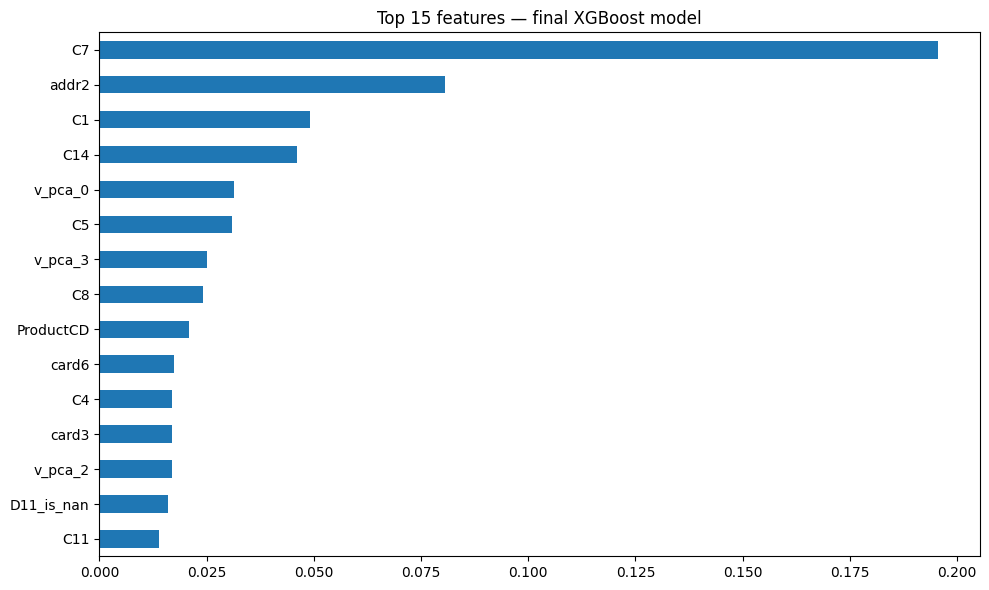

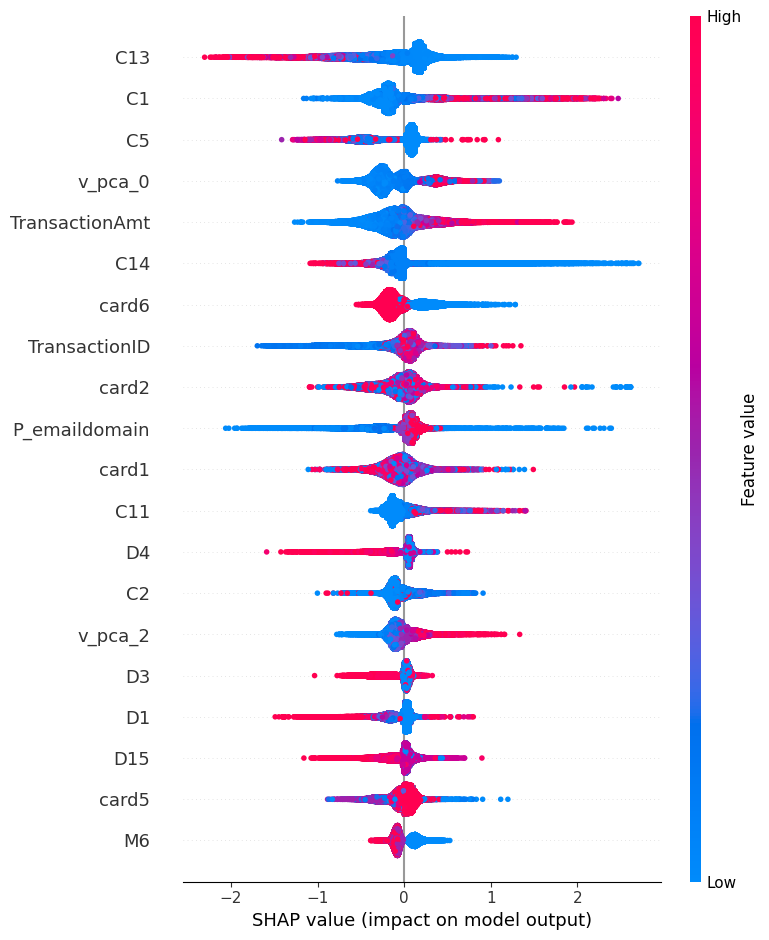

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 — EXPLAINABILITY
# ─────────────────────────────────────────────────────────────────────────────

feat_importances = pd.Series(
    final_model.feature_importances_, index=X_train_clean.columns
)
feat_importances.nlargest(15).sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Top 15 features — final XGBoost model")
plt.tight_layout()
plt.show()

# Use val for SHAP — test stays blind
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_val_clean)
shap.summary_plot(shap_values, X_val_clean)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9 — PRODUCTION INFERENCE
# ─────────────────────────────────────────────────────────────────────────────

#
# raw         = pd.read_csv("new_transactions.csv")
# X_clean     = pipeline.transform(raw)
# X_clean.drop(columns=["date"], inplace=True, errors="ignore")
# predictions = final_model.predict_proba(X_clean)[:, 1]